## NumPy ufuncs
What are ufuncs?
ufuncs stands for "Universal Functions" and they are NumPy functions that operate on the ndarray object.

**Why use ufuncs?**

ufuncs are used to implement vectorization in NumPy which is way faster than iterating over elements.

They also provide broadcasting and additional methods like reduce, accumulate etc. that are very helpful for computation.

ufuncs also take additional arguments, like:

`where` boolean array or condition defining where the operations should take place.

`dtype` defining the return type of elements.

`out` output array where the return value should be copied.

In [33]:
import numpy as np
from math import log

### What is Vectorization?
Converting iterative statements into a vector based operation is called vectorization.
Vectorization means applying an operation to an entire array at once instead of looping element by element.
It is faster as modern CPUs are optimized for such operations.
```
# not vectorized - slow
result = []
for x in arr:
    result.append(x * 2)

# vectorized - fast
result = arr * 2
```
Same output, but the vectorized version pushes the loop down to C level inside NumPy — no Python overhead per element.
That's essentially what ufuncs do — they're the mechanism that makes vectorization work in NumPy.

**Add the Elements of Two Lists**

list 1: `[1, 2, 3, 4]`

list 2: `[4, 5, 6, 7]`

One way of doing it is to iterate over both of the lists and then sum each elements.

In [34]:
"""
ufunc (universal function) is a NumPy function that operates element-wise on arrays.
Instead of looping through each element yourself:

# slow - python loop
result = [x**2 for x in arr]

# fast - ufunc
result = np.square(arr)

Under the hood, ufuncs are implemented in C, so they're much faster than Python loops.
Most NumPy math operators (+, *, etc.) are actually ufuncs under the hood — so when you write arr * 2, NumPy is calling a ufunc.
"""
arr = np.array([1, 2, 3, 4])

print(np.add(arr, 10))        # [11 12 13 14]
print(np.multiply(arr, 2))    # [2 4 6 8]
print(np.sqrt(arr))           # [1. 1.41 1.73 2.]
print(np.square(arr))         # [1 4 9 16]

[11 12 13 14]
[2 4 6 8]
[1.         1.41421356 1.73205081 2.        ]
[ 1  4  9 16]


In [35]:
# Without ufunc, we can use Python's built-in zip() method:

x = [1, 2, 3, 4]
y = [4, 5, 6, 7]
z = []

for i, j in zip(x, y):
  z.append(i + j)
print(z)


[5, 7, 9, 11]


In [36]:
# With ufunc, we can use the add() function:
x = [1, 2, 3, 4]
y = [4, 5, 6, 7]
z = np.add(x, y)
print(z)

[ 5  7  9 11]


**How To Create Your Own ufunc**<br>
To create your own ufunc, you have to define a function, like you do with normal functions in Python, then you add it to your NumPy ufunc library with the frompyfunc() method.

The `frompyfunc()` method takes the following arguments:

- `function` - the name of the function.
- `inputs` - the number of input arguments (arrays).
- `outputs` - the number of output arrays.

In [37]:
def my_add(x, y):
    return  x + y

my_add = np.frompyfunc(my_add, 2, 1)
print(my_add([1, 2, 3, 4], [5, 6, 7, 8]))

[6 8 10 12]


In [38]:
# check if a function is ufunc
# Check the type of a function to check if it is a ufunc or not.
# A ufunc should return <class 'numpy.ufunc'>.
print(type(np.add))
print(type(np.concatenate))

# we can also use if statement to check if the function is a ufunc or not:
if type(np.add) == np.ufunc:
    print("add function is ufunc")
else:
    print("add function is not ufunc")

<class 'numpy.ufunc'>
<class 'numpy._ArrayFunctionDispatcher'>
add function is ufunc


In [39]:
# arithmetic operators + - * / directly between NumPy arrays with ufunc called under the hood
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

print(a + b)   # [11 22 33 44]
print(a - b)   # [-9 -18 -27 -36]
print(a * b)   # [10 40 90 160]
print(a / b)   # [0.1 0.1 0.1 0.1]
print(a % b)
print(b ** a)

[11 22 33 44]
[ -9 -18 -27 -36]
[ 10  40  90 160]
[0.1 0.1 0.1 0.1]
[1 2 3 4]
[     10     400   27000 2560000]


In [40]:
# # arithmetic operators + - * / directly between NumPy arrays with ufunc called explicitly
arr1 = np.array([10, 20, 30, 40, 50, 60])
arr2 = np.array([20, 21, 22, 23, 24, 25])
print(np.add(arr1, arr2))
print(np.subtract(arr1, arr2))
print(np.multiply(arr1, arr2))
print(np.divide(arr1, arr2))
print(np.power(arr1, arr2))
print(np.remainder(arr1, arr2))
print(np.mod(arr1, arr2))
print(divmod(arr1, arr2)) # quotient and mod
arr = np.array([-1, -2, 1, 2, 3, -4])
print(np.absolute(arr))

[30 41 52 63 74 85]
[-10  -1   8  17  26  35]
[ 200  420  660  920 1200 1500]
[0.5        0.95238095 1.36363636 1.73913043 2.08333333 2.4       ]
[ 7766279631452241920 -5135277853620830208  8433224401192747008
                    0  8120319428677074944  6213841585864441856]
[10 20  8 17  2 10]
[10 20  8 17  2 10]
(array([0, 0, 1, 1, 2, 2]), array([10, 20,  8, 17,  2, 10]))
[1 2 1 2 3 4]


In [41]:
# where lets you apply the operation only where the condition is True
import numpy as np

a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])
result = np.zeros(4, dtype=int)

np.add(a, b, where=[True, False, True, False], out=result)
print(result)

[11  0 33  0]


In [42]:
"""
Rounding Decimals
There are primarily five ways of rounding off decimals in NumPy:

truncation
fix
rounding
floor
ceil
"""
#Truncation: Remove the decimals, and return the float number closest to zero. Use the trunc() and fix() functions.
print(np.trunc([-3.1666, 3.6667]))
print(np.fix([-3.1666, 3.6667]))


[-3.  3.]
[-3.  3.]


In [43]:
#Rounding: The around() function increments preceding digit or decimal by 1 if >=5 else do nothing. E.g. round off to 1 decimal point, 3.16666 is 3.2
print(np.around(3.1666, 2))

3.17


In [44]:
# Floor: The floor() function rounds off decimal to nearest lower integer. E.g. floor of 3.166 is 3.f
print(np.floor([-3.1666, 3.6667]))

[-4.  3.]


In [45]:
# Ceil: The ceil() function rounds off decimal to nearest upper integer. E.g. ceil of 3.166 is 4.

print(np.ceil([-3.1666, 3.6667]))

[-3.  4.]


In [46]:
"""
Logs
NumPy provides functions to perform log at the base 2, e and 10.
We will also explore how we can take log for any base by creating a custom ufunc.
All of the log functions will place -inf or inf in the elements if the log can not be computed.
"""
# loge at base 2
print(np.arange(1, 10)) # creates an array of evenly spaced values within a range line range() but returns an numpy ndarray instead of a range object
arr = np.arange(1, 10)
print(np.log2(arr))

[1 2 3 4 5 6 7 8 9]
[0.         1.         1.5849625  2.         2.32192809 2.5849625
 2.80735492 3.         3.169925  ]


In [47]:
# Log at Base 10: Use the log10() function to perform log at the base 10.
arr = np.arange(1, 11)
print(np.log10(arr))

[0.         0.30103    0.47712125 0.60205999 0.69897    0.77815125
 0.84509804 0.90308999 0.95424251 1.        ]


In [48]:
# Natural Log, or Log at Base eUse the log() function to perform log at the base e.
arr = np.arange(1, 10)
print(np.log(arr))

[0.         0.69314718 1.09861229 1.38629436 1.60943791 1.79175947
 1.94591015 2.07944154 2.19722458]


In [72]:
# Log at Any Base: NumPy does not provide any function to take log at any base, so we can use the frompyfunc() function along with inbuilt function math.log() with two input parameters and one output parameter:

nplog = np.frompyfunc(log, 2, 1)
# the fist number is the log number and the second one is the base
print(nplog(225, 15))
print(nplog([100, 200, 300], 15))


2.0
[1.7005483074552052 1.9565063322650205 2.106232178537418]


In [50]:
"""
Summations:
What is the difference between summation and addition?
Addition is done between two arguments whereas summation happens over n elements.
"""

# Sum the values in arr1 and the values in arr2:

arr1 = np.array([1, 2, 3])
arr2 = np.array([1, 2, 3])

newarr = np.sum([arr1, arr2])

print(newarr)


12


In [51]:
# Perform summation in the following array over 1st axis:

arr1 = np.array([1, 2, 3])
arr2 = np.array([1, 2, 3])

newarr = np.sum([arr1, arr2], axis=1)
print(newarr)

[6 6]


In [52]:
"""
Cumulative sum means partially adding the elements in array.
E.g. The partial sum of [1, 2, 3, 4] would be [1, 1+2, 1+2+3, 1+2+3+4] = [1, 3, 6, 10].
Perform partial sum with the cumsum() function.
"""

# Perform cumulative summation in the following array:

arr = np.array([1, 2, 3])
print(np.cumsum(arr))

[1 3 6]


In [53]:
# To find the product of the elements in an array, use the prod() function.
arr = np.array([1, 2, 3, 4])
print(np.prod(arr))
# 24 because 1*2*3*4 = 24

24


In [54]:
# Find the product of the elements of two arrays:
arr1 = np.array([1, 2, 3, 4])
arr2 = np.array([5, 6, 7, 8])

print(np.prod([arr1, arr2]))
# 40320 because 1*2*3*4*5*6*7*8 = 40320


40320


In [55]:
# If you specify axis=1, NumPy will return the product of each array.
arr1 = np.array([1, 2, 3, 4])
arr2 = np.array([5, 6, 7, 8])
print(np.prod([arr1, arr2], axis=1))


[  24 1680]


In [56]:
"""
Cumulative product means taking the product partially.
E.g. The partial product of [1, 2, 3, 4] is [1, 1*2, 1*2*3, 1*2*3*4] = [1, 2, 6, 24]
Perform partial sum with the cumprod() function.
"""
arr = np.array([5, 6, 7, 8])
print(np.cumprod(arr))

[   5   30  210 1680]


In [57]:
"""
A discrete difference means subtracting two successive elements.
E.g. for [1, 2, 3, 4], the discrete difference would be [2-1, 3-2, 4-3] = [1, 1, 1]
To find the discrete difference, use the diff() function.
"""
arr = np.array([5, 6, 7, 8])
print(np.diff(arr))

arr1 = np.array([10, 15, 25, 5])
print(np.diff(arr1))

# we can do the discrete difference more than one time by determining the n parameter
arr2 = np.array([10, 15, 25, 5])
print(np.diff(arr2, n=2))
# [5 -30] because: 15-10=5, 25-15=10, and 5-25=-20 AND 10-5=5 and -20-10=-30

[1 1 1]
[  5  10 -20]
[  5 -30]


In [58]:
"""
LCM (Least Common Multiple) The smallest integer  m such that a / m and b / m (both a and b divide into m evenly).   lcm(4,6)=12
Because multiples of 4: 4, 8, 12, 16... and multiples of 6: 6, 12, 18... → smallest common multiple is 12.
"""

num1 = 4
num2 = 6
# 12 because that is the lowest common multiple of both numbers (4*3=12 and 6*2=12).
print(np.lcm(num1, num2))

# To find the Lowest Common Multiple of all values in an array, you can use the reduce() method.
arr = np.array([3, 6, 9])
print(np.lcm.reduce(arr))

arr = np.arange(1, 11)
print(np.lcm.reduce(arr))

12
18
2520


In [59]:
"""
GCD (Greatest Common Divisor) The largest integer d such that d /a  and d / b (d divides both a and b with no remainder).
gdc(12,8)=4
Because factors of 12: 1, 2, 3, 4, 6, 12 and factors of 8: 1, 2, 4, 8 → largest common factor is 4.
"""
num1 = 10
num2 = 4
# 3 because that is the highest number both numbers can be divided by (6/3=2 and 9/3=3).
print(np.gcd(num1, num2))

# To find the Highest Common Factor of all values in an array, you can use the reduce() method.
arr = np.array([20, 8, 32, 36, 16])
print(np.gcd.reduce(arr))

2
4


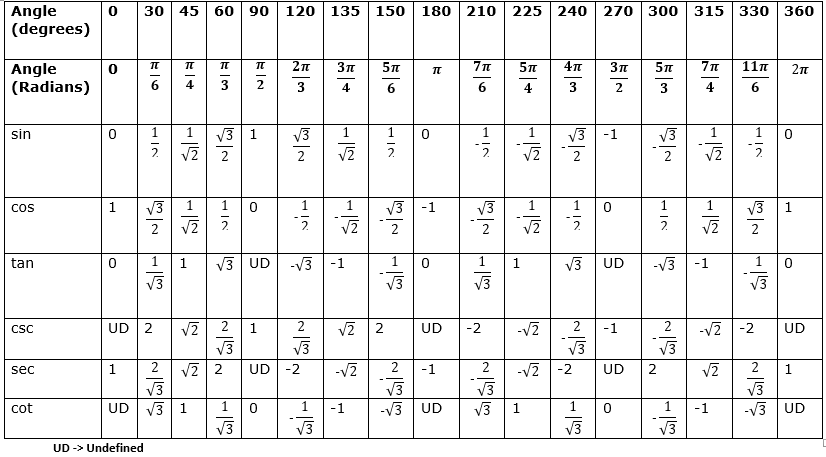

In [91]:
"""
Trigonometric Functions
NumPy provides the ufuncs sin(), cos() and tan() that take values in radians and produce the corresponding sin, cos and tan values.
"""

print(np.sin( np.pi / 2))
print(np.sin(np.array([np.pi/2, np.pi/3, np.pi/4, np.pi/6])))
print(np.cos(np.array([np.pi/2, np.pi/3, np.pi/4, np.pi/6])))
print(np.tan(np.array([np.pi/2, np.pi/3, np.pi/4, np.pi/6])))

1.0
[1.         0.8660254  0.70710678 0.5       ]
[6.12323400e-17 5.00000000e-01 7.07106781e-01 8.66025404e-01]
[1.63312394e+16 1.73205081e+00 1.00000000e+00 5.77350269e-01]


In [94]:
# converting degree to Radian
print(np.deg2rad(np.array([90, 180, 270, 360])))
# converting radian to degree
print(np.rad2deg(np.array([np.pi/2, np.pi, 1.5*np.pi, 2*np.pi])))


[1.57079633 3.14159265 4.71238898 6.28318531]
[ 90. 180. 270. 360.]


In [106]:
"""
Finding Angles
Finding angles from values of sine, cos, tan. E.g. sin, cos and tan inverse (arcsin, arccos, arctan).

NumPy provides ufuncs arcsin(), arccos() and arctan() that produce radian values for corresponding sin, cos and tan values given.
"""
print(np.rad2deg(np.arcsin(1/2)))
print(np.rad2deg(np.arccos(1)))
print(np.rad2deg(np.arctan(1)))

# Angels of array
print(np.rad2deg(np.arcsin(np.array([1, -1, 0.1]))))
print(np.rad2deg(np.arccos(np.array([1, -1, 0.1]))))
print(np.rad2deg(np.arctan(np.array([1, -1, 0.1]))))


30.000000000000004
0.0
45.0
[ 90.         -90.           5.73917048]
[  0.         180.          84.26082952]
[ 45.         -45.           5.71059314]


In [107]:
"""
Finding hypotenues using pythagoras theorem in NumPy.

NumPy provides the hypot() function that takes the base and perpendicular values and produces hypotenues based on pythagoras theorem.
"""

base = 3
prep = 4
print(np.hypot(base, prep))

5.0


In [108]:
"""
Sets in numpy
We can use NumPy's unique() method to find unique elements from any array. E.g. create a set array, but remember that the set arrays should only be 1-D arrays.
"""

arr = np.array([1, 1, 1, 2, 3, 4, 5, 5, 6, 7])
x = np.unique(arr)
print(x)

[1 2 3 4 5 6 7]


In [115]:
arr1 = np.array([1, 2, 3, 4])
arr2 = np.array([3, 4, 5, 6])
# To find the unique values of two arrays, use the union1d() method
print(np.union1d(arr1, arr2))

# To find only the values that are present in both arrays, use the intersect1d() method.
print(np.intersect1d(arr1, arr2))

#  the intersect1d() method takes an optional argument assume_unique, which if set to True can speed up computation. It should always be set to True when dealing with sets.
print(np.intersect1d(arr1, arr2, assume_unique=True))

# To find only the values in the first set that is NOT present in the seconds set, use the setdiff1d() method.
print(np.setdiff1d(arr1, arr2, assume_unique=True))

# To find only the values that are NOT present in BOTH sets, use the setxor1d() method.
print(np.setxor1d(arr1, arr2, assume_unique=True))

[1 2 3 4 5 6]
[3 4]
[3 4]
[1 2]
[1 2 5 6]
